In [8]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics
import scripts.algorithms

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)
importlib.reload(scripts.algorithms)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
dsetname = "adult"
dsetnamex = "Adult"
d = 14

######
graphsx = np.load("../graphs/"+dsetname+"_knn_random.npy", allow_pickle=True)


## Info on the graphs

In [3]:
######
randomgraphsinfo = pd.read_csv("../graphs/adult_knn_graphsummary.npy")
randomgraphsinfo


,Dataset (d),kmax,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Adult (14),1,328,46,10,36,1.0,0.213415,0.786585,7.130435,0.031998,0.006694,0.025304,70,258,0,0,0
1,Adult (14),2,328,49,12,37,2.0,0.484756,1.515244,13.387755,0.111602,0.029089,0.082513,15,184,0,0,1
2,Adult (14),3,328,49,12,37,3.0,0.777439,2.222561,20.081633,0.270381,0.084564,0.185817,4,121,0,0,2
3,Adult (14),4,328,49,12,37,4.0,1.076220,2.923780,26.775510,0.487283,0.173249,0.314034,2,86,0,0,3
4,Adult (14),5,328,49,12,37,5.0,1.405488,3.594512,33.469388,0.764768,0.300608,0.464161,1,61,0,0,4
5,Adult (14),6,328,49,12,37,6.0,1.725610,4.274390,40.163265,1.108693,0.453662,0.655031,0,44,0,0,5
6,Adult (14),7,328,49,12,37,7.0,2.009146,4.990854,46.857143,1.502890,0.601197,0.901693,0,33,0,0,6
7,Adult (14),8,328,49,12,37,8.0,2.347561,5.652439,53.551020,1.963527,0.794119,1.169408,0,19,0,0,7
8,Adult (14),9,328,49,12,37,9.0,2.689024,6.310976,60.244898,2.481875,1.012643,1.469232,0,12,0,0,8
9,Adult (14),10,328,49,12,37,10.0,2.957317,7.042683,66.938776,3.037052,1.209797,1.827254,0,10,0,0,9


## Learning

In [4]:
summary_dfx = scripts.algorithms.learn_greedy(datagraphs=graphsx, 
                                               dim=d,
                                               savedname=dsetname,
                                               thresh=False)

summary_dfx.to_csv("./ls_results/"+dsetname+"_learn_results_knn.csv", index=False)
summary_dfx.head(10)

,K,dataset,graphid,kmax,n,m,tr_utility,ts_utility,tr_size,ts_size,...,ts_only-Ns,tr_empty_adj,ts_empty_adj,tr_perf1,ts_perf1,tr_perf2,ts_perf2,tr_perf3,ts_perf3,greedyTime
0,1,adult (14),0,1,328,46,49.190,20.810,229.0,99.0,...,78.19,0.0,0.0,100.00000,100.00000,21.48033,21.02020,0.00000,0.00000,0.031058
1,2,adult (14),0,1,328,46,49.190,20.810,229.0,99.0,...,78.19,0.0,0.0,100.00000,100.00000,21.48033,21.02020,0.00000,0.00000,0.032218
2,3,adult (14),0,1,328,46,49.190,20.810,229.0,99.0,...,78.19,0.0,0.0,100.00000,100.00000,21.48033,21.02020,0.00000,0.00000,0.031374
3,4,adult (14),0,1,328,46,49.190,20.810,229.0,99.0,...,78.19,0.0,0.0,100.00000,100.00000,21.48033,21.02020,0.00000,0.00000,0.030803
4,5,adult (14),0,1,328,46,49.190,20.810,229.0,99.0,...,78.19,0.0,0.0,100.00000,100.00000,21.48033,21.02020,0.00000,0.00000,0.031186
5,1,adult (14),1,2,328,49,66.525,27.295,229.0,99.0,...,55.97,0.0,0.0,65.88332,63.39259,29.05024,27.57076,61.94999,59.08953,0.059137
6,2,adult (14),1,2,328,49,76.210,31.470,229.0,99.0,...,55.97,0.0,0.0,75.47554,73.11569,33.27943,31.78784,72.64840,69.93656,0.114691
7,3,adult (14),1,2,328,49,84.760,36.240,229.0,99.0,...,55.97,0.0,0.0,83.94291,84.20808,37.01313,36.60605,82.09264,82.35720,0.173268
8,4,adult (14),1,2,328,49,88.460,37.180,229.0,99.0,...,55.97,0.0,0.0,87.60916,86.40090,38.62892,37.55553,86.18244,84.80877,0.225770
9,5,adult (14),1,2,328,49,91.535,37.935,229.0,99.0,...,55.97,0.0,0.0,90.65616,88.16352,39.97159,38.31814,89.58050,86.77344,0.281519


## Plots

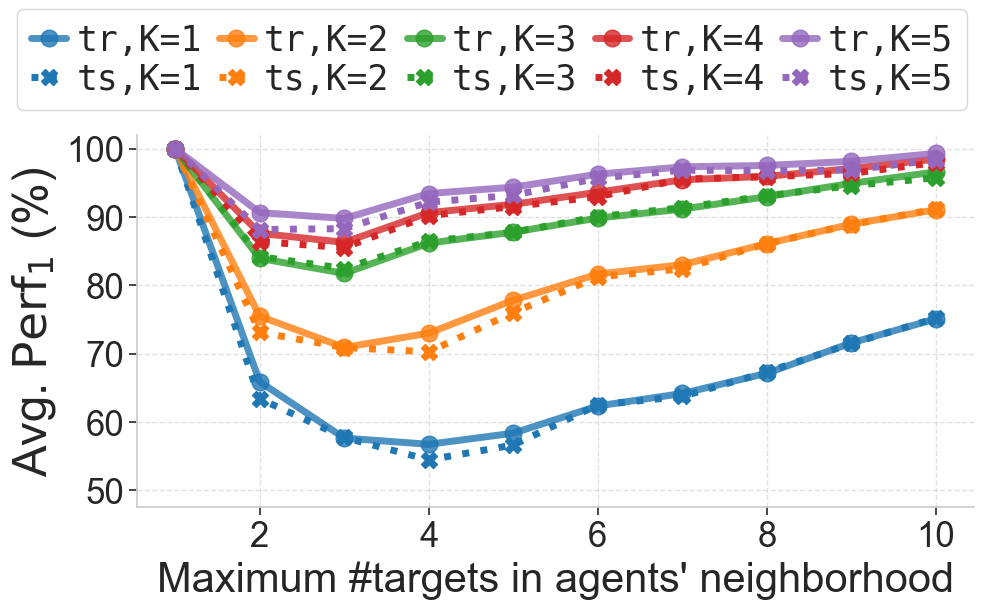

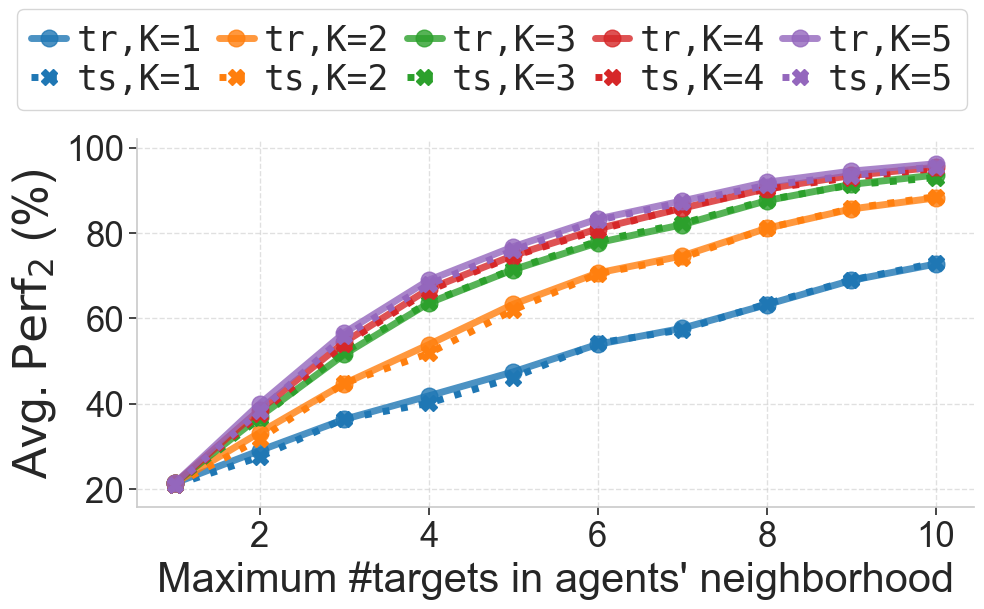

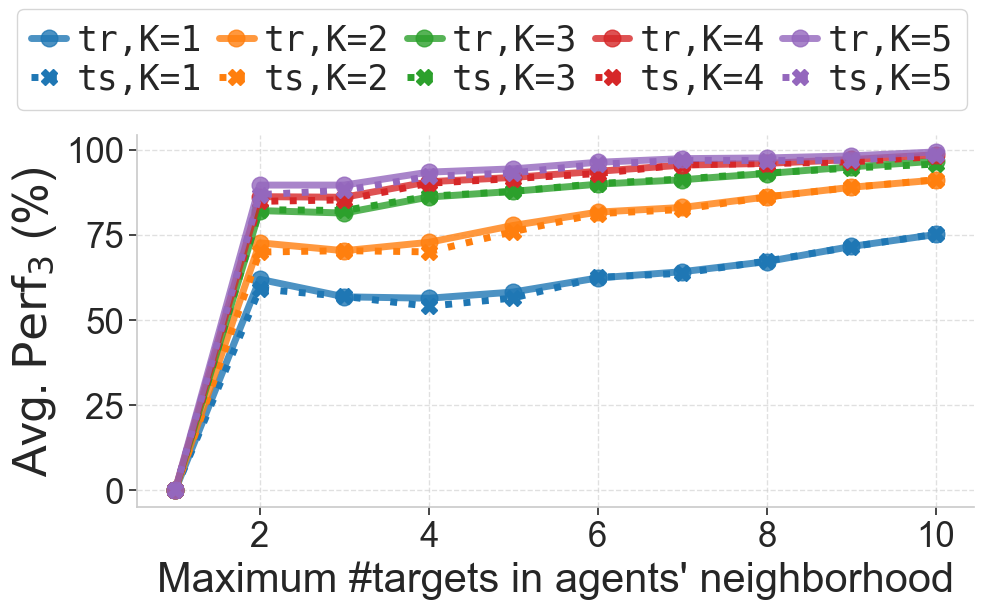

In [9]:
######### exclude: no neighbors and exclusively neg neighbors
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=False, 
                  perfv="perf1", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_knn_perf1.pdf")

######### exclude: none
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=False, 
                  perfv="perf2", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_knn_perf2.pdf")

######### exclude: no neighbors and exclusively neg/pos neighbors
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=False, 
                  perfv="perf3", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_knn_perf3.pdf")

